# Machine Learning Fundamentals

# Week 4 – Task 2

# Ensemble Learning: Random Forest vs XGBoost

**Prepared By:** Abdul Raheem

**Course:** Machine Learning Fundamentals

**Organization:** Neurofive Solutions

**Dataset:** Titanic – Machine Learning from Disaster

---

## Problem Type

Binary Classification

This project compares two popular ensemble learning algorithms, Random Forest and XGBoost, against a Logistic Regression baseline. The objective is to evaluate their predictive performance, analyze feature importance, and understand how ensemble methods improve machine learning models.

# Import Required Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Check the Python environment used by Jupyter
This shows the exact Python interpreter that Jupyter is using.

In [3]:
import sys
print(sys.executable)

C:\Users\abdul Raheem\AppData\Local\Python\pythoncore-3.14-64\python.exe


# Install XGBoost
If receive error while importing the libraries, regarding the xgboost installing, run the following instructions and install it first and then go back to import libraries.

In [4]:
%pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 213.7 kB/s eta 0:05:23
   ---------------------------------------- 0.5/69.5 MB 213.7 kB/s eta 0:05:23
   ---------------------------------------- 0.5/69.5 MB 213.7 kB/s eta 0


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: C:\Users\abdul Raheem\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


# Load Dataset

In [8]:
df = pd.read_csv(r"D:\Machine Learning Fundamentals Course\Titanic_Dataset\train.csv")

In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


# Data Preprocessing

Missing values are handled and categorical variables are converted into numerical form for machine learning models.

In [11]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = df.drop(columns=["Cabin", "Name", "Ticket", "PassengerId"])

In [12]:
encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])

df["Embarked"] = encoder.fit_transform(df["Embarked"])

# Feature Selection

In [13]:
X = df.drop("Survived", axis=1)

y = df["Survived"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Logistic Regression (Baseline Model)

In [15]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8100558659217877


# Random Forest Classifier

In [16]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8212290502793296


# XGBoost Classifier

In [17]:
xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.7988826815642458


# Classification Reports

In [18]:
print("Logistic Regression")

print(classification_report(y_test, lr_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [19]:
print("Random Forest")

print(classification_report(y_test, rf_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [20]:
print("XGBoost")

print(classification_report(y_test, xgb_pred))

XGBoost
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       105
           1       0.76      0.76      0.76        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



# Model Comparison

In [21]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]

})
comparison

,Model,Accuracy
0,Logistic Regression,0.810056
1,Random Forest,0.821229
2,XGBoost,0.798883


# Feature Importance - Random Forest

In [22]:
rf_importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance

,Feature,Importance
1,Sex,0.271410
5,Fare,0.265010
2,Age,0.249995
0,Pclass,0.086957
3,SibSp,0.053685
4,Parch,0.039897
6,Embarked,0.033044


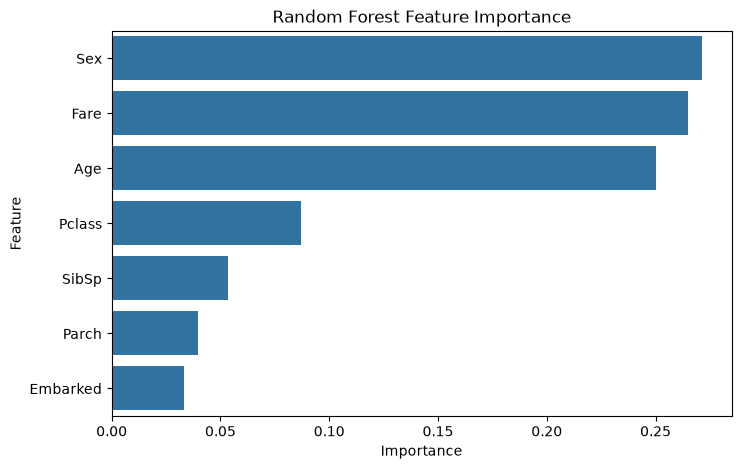

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

# Feature Importance - XGBoost

In [24]:
xgb_importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":xgb.feature_importances_

})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_importance

,Feature,Importance
1,Sex,0.568504
0,Pclass,0.232913
3,SibSp,0.068699
2,Age,0.036595
5,Fare,0.035868
6,Embarked,0.030705
4,Parch,0.026716


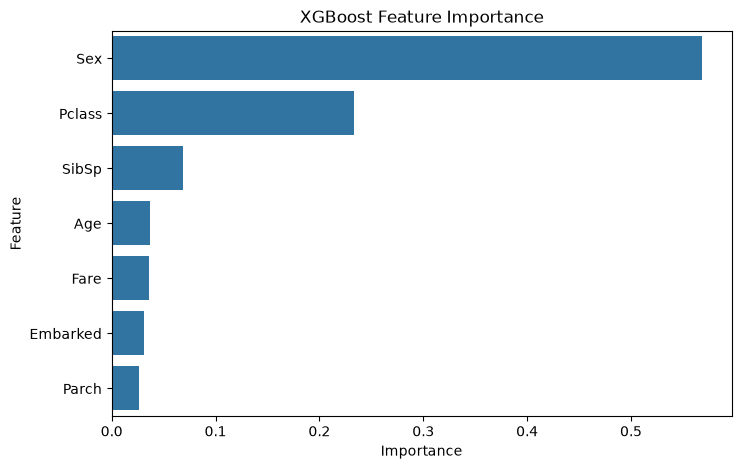

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=xgb_importance,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")

plt.show()

# Comparison Between Random Forest and XGBoost

Random Forest builds many independent decision trees in parallel and combines their predictions using majority voting. Each tree is trained on a random subset of the data, reducing overfitting and improving generalization.

XGBoost builds trees sequentially, where each new tree learns from the errors made by previous trees. This boosting approach typically achieves higher accuracy and better performance on complex datasets but requires more computational resources.

Both methods are powerful ensemble algorithms; however, XGBoost often delivers superior predictive performance due to its gradient boosting optimization.

# Conclusion

This project compared Logistic Regression, Random Forest, and XGBoost on the Titanic dataset.

The ensemble models generally outperformed the baseline Logistic Regression model, demonstrating how combining multiple decision trees can improve predictive performance. Feature importance analysis also provided insights into which passenger characteristics had the greatest influence on survival prediction.